In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\Mike\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [11]:
#adjustable parameters

from Classifiers import NaiveClassifier, PretrainedClassifier

num_epochs   = 40
lr           = 3e-4 #same lr for both to reduce confounding variables
batch_size   = 256
num_classes  = 8    
latent_dim   = 256
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

naive_classifier = NaiveClassifier(num_classes).to(device)
pretrained_classifier = PretrainedClassifier(latent_dim, num_classes).to(device)


naive_optimizer = optim.Adam(naive_classifier.parameters(), lr=lr, weight_decay=weight_decay)
pretrained_optimizer = optim.Adam(pretrained_classifier.parameters(), lr=lr, weight_decay=weight_decay)

Data Configuration

In [3]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#one pathology per image / equal number of images per pathology
full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

Frozen Encoder Converting Images to Latent Space

In [12]:
#Encoding images to latent space
from AutoEncoder import Encoder

weights = torch.load("models\\oct_encoder.pth", map_location=device)
encoder = Encoder(latent_dim=latent_dim)
encoder.load_state_dict(weights)
encoder = encoder.to(device)
encoder.eval()

start_time = time.perf_counter()

train_features = []
labels_list = []

with torch.no_grad():
    for images, batch_labels in train_loader:
        images = images.to(device)
        pretrained = encoder(images)
        train_features.append(pretrained.cpu())
        labels_list.append(batch_labels)

train_features = torch.cat(train_features)
all_labels = torch.cat(labels_list)

train_encode_time = time.perf_counter() - start_time

pretrained_dataset = TensorDataset(train_features, all_labels)

pretrained_loader = DataLoader(
    pretrained_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)


#encoding val images
start_time = time.perf_counter()

val_features = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        pretrained = encoder(images)

        val_features.append(pretrained.cpu())
        val_labels.append(labels)

val_features = torch.cat(val_features)
val_labels = torch.cat(val_labels)
val_encode_time = time.perf_counter() - start_time

pretrained_val_dataset = TensorDataset(val_features, val_labels)

pretrained_val_loader = DataLoader(
    dataset=pretrained_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


print(
    f"Training: {len(train_features)} samples, "
    f"Validation: {len(val_features)} samples"
)

print(
    f"Encoding time: "
    f"Train={train_encode_time:.1f}s, "
    f"Val={val_encode_time:.1f}s"
)

Training: 18400 samples, Validation: 2800 samples
Encoding time: Train=32.3s, Val=18.8s


Training

In [13]:
#training pretrained - classifier: 2 linear layers
start_time = time.perf_counter()

pretrained_train_losses = []
pretrained_val_losses = []

for epoch in range(num_epochs):
    pretrained_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for pretrained, labels in pretrained_loader:
        pretrained = pretrained.to(device)
        labels = labels.to(device)

        output = pretrained_classifier(pretrained)
        loss = criterion(output, labels)

        pretrained_optimizer.zero_grad()
        loss.backward()
        pretrained_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)    
    accuracy = 100 * correct / total
    end_time = time.perf_counter() - start_time
    pretrained_train_losses.append(epoch_train_loss)

    #val
    pretrained_classifier.eval()
    
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for pretrained, labels in pretrained_val_loader:
            pretrained, labels = pretrained.to(device), labels.to(device)
            
            output = pretrained_classifier(pretrained)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    pretrained_val_losses.append(epoch_val_loss)
    

    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    
end_time = time.perf_counter()

pretrained_accuracy = epoch_val_accuracy
pretrained_train_time = end_time - start_time

print(
    f"Results: Accuracy={pretrained_accuracy:.2f}% "
    f"Training Duration={pretrained_train_time:.6f} sec"
)

Epoch 1: Training: Loss=1.8429, Accuracy=26.08%      Validation: Loss=1.5583, Val Acc=39.00%
Epoch 2: Training: Loss=1.4579, Accuracy=38.76%      Validation: Loss=1.3017, Val Acc=44.21%
Epoch 3: Training: Loss=1.3000, Accuracy=40.80%      Validation: Loss=1.2082, Val Acc=46.29%
Epoch 4: Training: Loss=1.2253, Accuracy=42.86%      Validation: Loss=1.1618, Val Acc=47.71%
Epoch 5: Training: Loss=1.1845, Accuracy=44.33%      Validation: Loss=1.1296, Val Acc=49.32%
Epoch 6: Training: Loss=1.1548, Accuracy=45.53%      Validation: Loss=1.1087, Val Acc=49.79%
Epoch 7: Training: Loss=1.1261, Accuracy=47.24%      Validation: Loss=1.0872, Val Acc=51.89%
Epoch 8: Training: Loss=1.1076, Accuracy=47.92%      Validation: Loss=1.0715, Val Acc=51.50%
Epoch 9: Training: Loss=1.0886, Accuracy=49.36%      Validation: Loss=1.0559, Val Acc=52.75%
Epoch 10: Training: Loss=1.0743, Accuracy=50.21%      Validation: Loss=1.0429, Val Acc=52.96%
Epoch 11: Training: Loss=1.0545, Accuracy=51.72%      Validation: Los

In [16]:
torch.save(pretrained_classifier.state_dict(), "models/pretrained_classifier.pth")

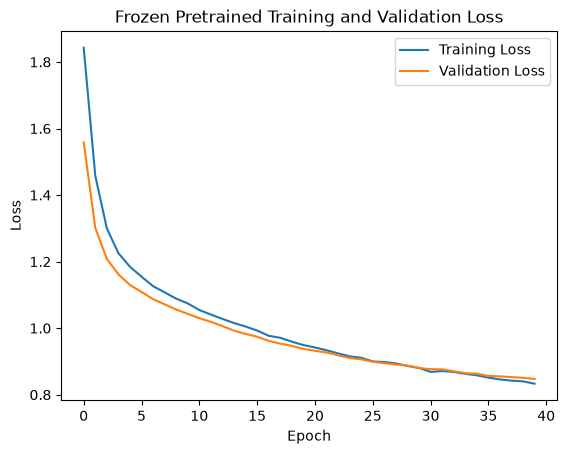

In [15]:
plt.plot(pretrained_train_losses, label="Training Loss")
plt.plot(pretrained_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen Pretrained Training and Validation Loss")
plt.legend()
plt.show()

Testing

In [ ]:
#test - pretrained

test_pretrained_classifier = PretrainedClassifier(256, 8).to(device)
test_pretrained_classifier.load_state_dict(torch.load("models/pretrained_classifier.pth", map_location=device))
test_pretrained_classifier.eval()
encoder.eval()

#temp scaling for confidence calibration
val_logits, val_targets = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        val_logits.append(test_pretrained_classifier(encoder(images)).cpu())
        val_targets.append(labels)

val_logits = torch.cat(val_logits)
val_targets = torch.cat(val_targets)

#temperature scaling for better confidence calibration
T = torch.ones(1, requires_grad=True)
opt = optim.LBFGS([T], lr=0.01, max_iter=50)

def closure():
    opt.zero_grad()
    loss = nn.CrossEntropyLoss()(val_logits / T, val_targets)
    loss.backward()
    return loss

opt.step(closure)
print("T =", T.item())


pretrained_correct = 0
top2_correct = 0
total = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
pretrained_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = test_pretrained_classifier(encoder(images))
        probs = torch.softmax(logits / T.item(), dim=1)
        conf, pretrained_predict = probs.max(dim=1)

        top2 = probs.topk(2, dim=1).indices
        top2_correct += (top2 == labels.unsqueeze(1)).any(dim=1).sum().item()

        #margin: how far ahead the winner is, instead of how much mass it holds
        conf = probs.topk(2, dim=1).values.diff(dim=1).abs().squeeze(1)

        hit = (pretrained_predict == labels)
        pretrained_correct += hit.sum().item()
        total += labels.size(0)

        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        for label, e_pred in zip(labels, pretrained_predict):
            l = label.item()
            class_total[l] += 1
            pretrained_class_correct[l] += int(l == e_pred.item())

print(f"Frozen Pretrained test accuracy: {100 * pretrained_correct / total:.2f}%")
print(f"Top-2 accuracy:                  {100 * top2_correct / total:.2f}%")
print(f"Confidence when right:           {100 * conf_right / pretrained_correct:.2f}%")
print(f"Confidence when wrong:           {100 * conf_wrong / n_wrong:.2f}%")
print()
print(f"{'Class':<10} {'Frozen Pretrained':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * pretrained_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

T = 0.8863317370414734
Frozen Pretrained test accuracy: 62.61%
Top-2 accuracy:                  84.54%
Confidence when right:           46.58%
Confidence when wrong:           18.97%

Class      Frozen Pretrained
AMD           100.00%
CNV            64.29%
CSR            69.43%
DME            50.00%
DR             60.29%
DRUSEN         38.86%
MH             61.14%
NORMAL         56.86%


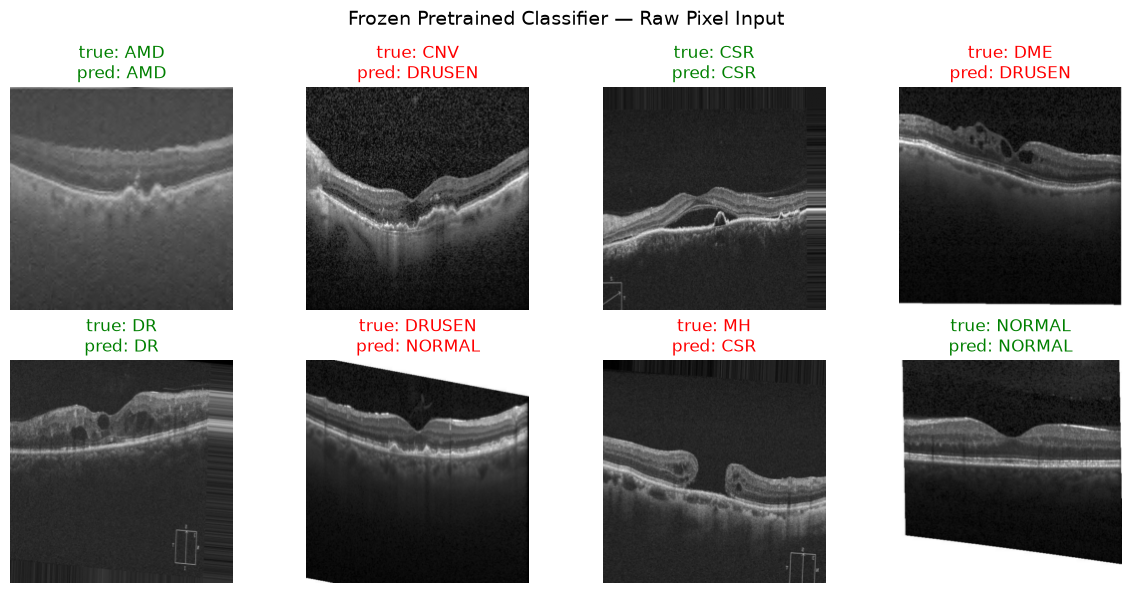

In [21]:
#visualizing results
found = {}
for images, labels in val_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

pretrained_classifier.eval()
with torch.no_grad():
    features = encoder(batch.to(device)).flatten(1)
    pred_ids = pretrained_classifier(features).argmax(dim=1).cpu().tolist()

class_names = val_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Frozen Pretrained Classifier — Raw Pixel Input", fontsize=14)

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.savefig("result_images/frozen_pretrained_results.png")
plt.show()